In [1]:
import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, LabelEncoder

In [3]:
# === Load your merged CSV (already created) ===
df = pd.read_csv("../data/raw/multi_stock_merged.csv", parse_dates=["Date"])

# === Sort by date and stock ===
df = df.sort_values(by=["Date", "Ticker"]).reset_index(drop=True)

# === Normalize numeric features PER stock ===
features = ["Open", "High", "Low", "Close", "Volume"]
df_scaled = df.copy()

for ticker in df["Ticker"].unique():
    mask = df["Ticker"] == ticker
    scaler = MinMaxScaler()
    df_scaled.loc[mask, features] = scaler.fit_transform(df.loc[mask, features])

# === Encode Ticker as Stock_ID ===
le = LabelEncoder()
df_scaled["Stock_ID"] = le.fit_transform(df_scaled["Ticker"])

# === Final column order ===
df_scaled = df_scaled[["Date", "Stock_ID"] + features]
df_scaled.head()

,Date,Stock_ID,Open,High,Low,Close,Volume
0,2014-01-02,0,0.831720,0.831900,0.833425,0.830865,0.008188
1,2014-01-02,1,0.086310,0.085614,0.086462,0.086626,0.005653
2,2014-01-02,2,0.350408,0.350233,0.354075,0.353440,0.024933
3,2014-01-02,3,0.005661,0.003270,0.005361,0.004700,0.120127
4,2014-01-02,4,0.000400,0.000371,0.000343,0.000414,0.006556


In [4]:
import numpy as np

def create_lstm_sequences(df, window_size=30, target_col="Close"):
    X_all, y_all = [], []

    # Make sure it's sorted by stock and date
    df = df.sort_values(by=["Stock_ID", "Date"]).reset_index(drop=True)

    # Loop through each stock separately
    for stock_id in df["Stock_ID"].unique():
        stock_df = df[df["Stock_ID"] == stock_id].reset_index(drop=True)

        # Drop the date column and keep only numeric features
        features = stock_df.drop(columns=["Date"]).values

        for i in range(window_size, len(stock_df)):
            X_all.append(features[i - window_size:i])
            y_all.append(features[i][df.columns.get_loc(target_col) - 1])  # -1 because 'Date' is dropped

    return np.array(X_all), np.array(y_all)


In [5]:
X, y = create_lstm_sequences(df_scaled, window_size=30)
print("X shape:", X.shape)  # [samples, 30, num_features]
print("y shape:", y.shape)  # [samples]


X shape: (14315, 30, 6)
y shape: (14315,)


In [6]:
# Time-based splits
n_total = len(X)
train_end = int(0.7 * n_total)
val_end   = int(0.85 * n_total)

X_train, y_train = X[:train_end], y[:train_end]
X_val, y_val     = X[train_end:val_end], y[train_end:val_end]
X_test, y_test   = X[val_end:], y[val_end:]


In [7]:
import torch
from torch.utils.data import Dataset, DataLoader

class StockDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Batch size
BATCH_SIZE = 64

# DataLoaders
train_loader = DataLoader(StockDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(StockDataset(X_val, y_val), batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(StockDataset(X_test, y_test), batch_size=BATCH_SIZE, shuffle=False)


In [8]:
for xb, yb in train_loader:
    print("X batch:", xb.shape)  # [64, 30, 6]
    print("y batch:", yb.shape)  # [64]
    break


X batch: torch.Size([64, 30, 6])
y batch: torch.Size([64])


In [9]:
import torch.nn as nn

class StockLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.2):
        super(StockLSTM, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)               # out: [batch, seq_len, hidden]
        out = out[:, -1, :]                 # take last time step
        out = self.fc(out)                  # [batch, 1]
        return out.squeeze()                # return shape: [batch]


In [11]:
INPUT_SIZE = X.shape[2]  # = 6
model = StockLSTM(input_size=INPUT_SIZE).to("cuda" if torch.cuda.is_available() else "cpu")

In [12]:
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


In [13]:
NUM_EPOCHS = 30

for epoch in range(NUM_EPOCHS):
    model.train()
    train_losses = []

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

    # Validation
    model.eval()
    val_losses = []
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb)
            loss = criterion(preds, yb)
            val_losses.append(loss.item())

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Train Loss: {np.mean(train_losses):.4f} | Val Loss: {np.mean(val_losses):.4f}")


Epoch 1/30 | Train Loss: 0.0110 | Val Loss: 0.0008
Epoch 2/30 | Train Loss: 0.0012 | Val Loss: 0.0008
Epoch 3/30 | Train Loss: 0.0011 | Val Loss: 0.0004
Epoch 4/30 | Train Loss: 0.0009 | Val Loss: 0.0004
Epoch 5/30 | Train Loss: 0.0009 | Val Loss: 0.0009
Epoch 6/30 | Train Loss: 0.0008 | Val Loss: 0.0005
Epoch 7/30 | Train Loss: 0.0007 | Val Loss: 0.0007
Epoch 8/30 | Train Loss: 0.0007 | Val Loss: 0.0005
Epoch 9/30 | Train Loss: 0.0006 | Val Loss: 0.0006
Epoch 10/30 | Train Loss: 0.0007 | Val Loss: 0.0001
Epoch 11/30 | Train Loss: 0.0006 | Val Loss: 0.0009
Epoch 12/30 | Train Loss: 0.0005 | Val Loss: 0.0001
Epoch 13/30 | Train Loss: 0.0005 | Val Loss: 0.0004
Epoch 14/30 | Train Loss: 0.0005 | Val Loss: 0.0002
Epoch 15/30 | Train Loss: 0.0005 | Val Loss: 0.0002
Epoch 16/30 | Train Loss: 0.0005 | Val Loss: 0.0003
Epoch 17/30 | Train Loss: 0.0005 | Val Loss: 0.0001
Epoch 18/30 | Train Loss: 0.0004 | Val Loss: 0.0001
Epoch 19/30 | Train Loss: 0.0004 | Val Loss: 0.0002
Epoch 20/30 | Train L

/var/folders/60/w45408950l338hfzlxx878vc0000gn/T/ipykernel_79564/131421885.py:28: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/homebrew/Caskroom/miniforge/base/envs/stockpredict/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


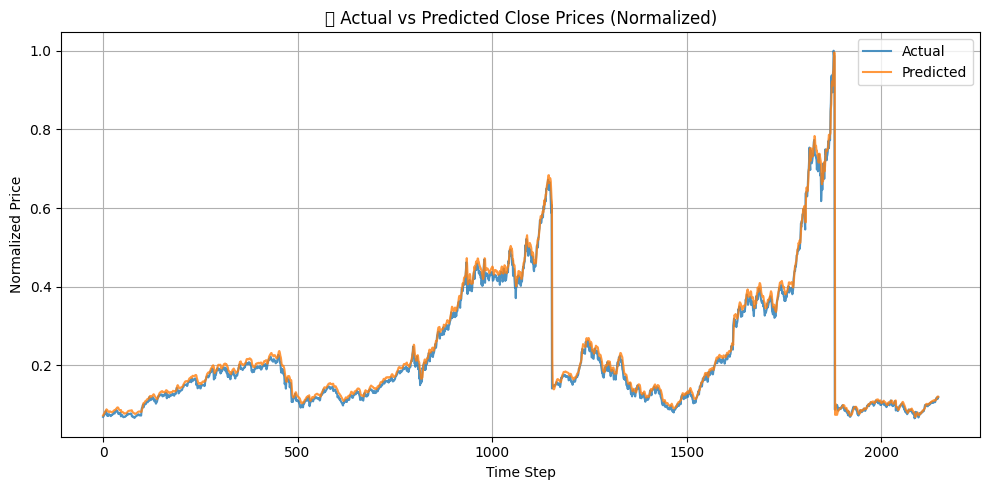

/var/folders/60/w45408950l338hfzlxx878vc0000gn/T/ipykernel_79564/131421885.py:39: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/homebrew/Caskroom/miniforge/base/envs/stockpredict/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


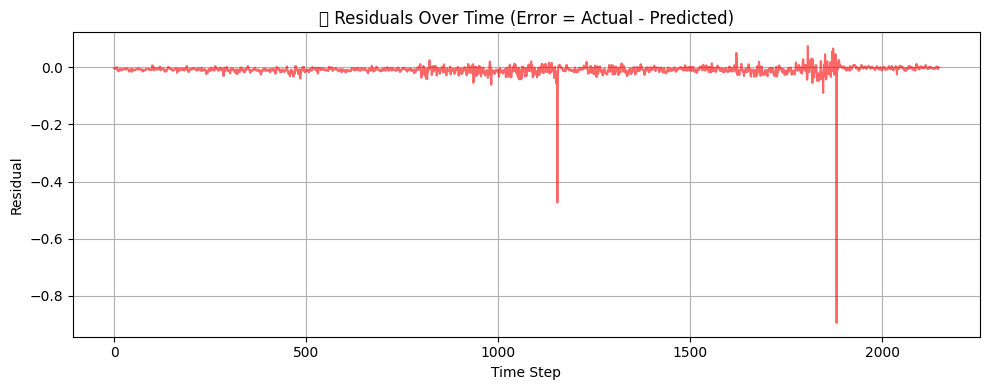

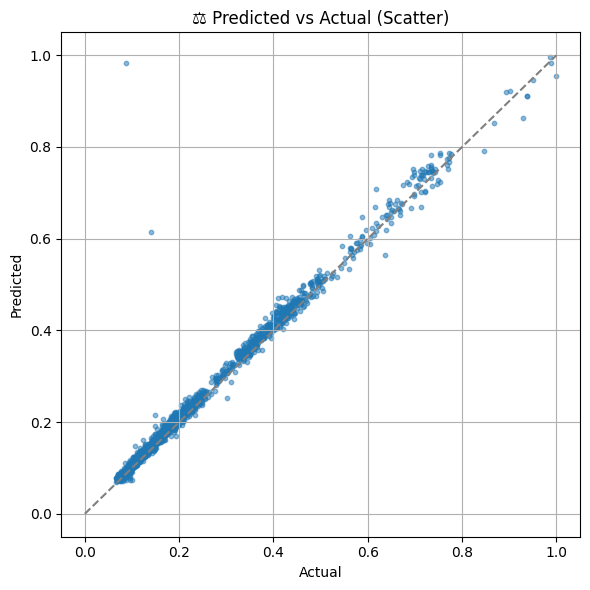

In [ ]:
import matplotlib.pyplot as plt
import torch

# Collect predictions on the test set
model.eval()
y_true = []
y_pred = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        preds = model(xb).cpu().numpy()
        y_pred.extend(preds)
        y_true.extend(yb.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Plot 1: Predicted vs Actual (Line Plot)
plt.figure(figsize=(10, 5))
plt.plot(y_true, label='Actual', alpha=0.8)
plt.plot(y_pred, label='Predicted', alpha=0.8)
plt.title("Actual vs Predicted Close Prices (Normalized)")
plt.xlabel("Time Step")
plt.ylabel("Normalized Price")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot 2: Residual Error (Actual - Predicted)
residuals = y_true - y_pred
plt.figure(figsize=(10, 4))
plt.plot(residuals, color='red', alpha=0.6)
plt.title("Residuals Over Time (Error = Actual - Predicted)")
plt.xlabel("Time Step")
plt.ylabel("Residual")
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot 3: Scatter Plot of Predictions
plt.figure(figsize=(6, 6))
plt.scatter(y_true, y_pred, alpha=0.5, s=10)
plt.plot([0, 1], [0, 1], '--', color='gray')
plt.title("Predicted vs Actual (Scatter)")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import pearsonr
import numpy as np

# Basic metrics
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)
corr, _ = pearsonr(y_true, y_pred)

# Display nicely
print("Evaluation Metrics on Test Set")
print(f"🔹 MSE  : {mse:.6f}")
print(f"🔹 RMSE : {rmse:.6f}")
print(f"🔹 MAE  : {mae:.6f}")
print(f"🔹 R²   : {r2:.4f}")
print(f"🔹 Pearson Correlation (r): {corr:.4f}")


Evaluation Metrics on Test Set
🔹 MSE  : 0.000660
🔹 RMSE : 0.025691
🔹 MAE  : 0.011081
🔹 R²   : 0.9743
🔹 Pearson Correlation (r): 0.9891


/var/folders/60/w45408950l338hfzlxx878vc0000gn/T/ipykernel_79564/4027431353.py:30: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/homebrew/Caskroom/miniforge/base/envs/stockpredict/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


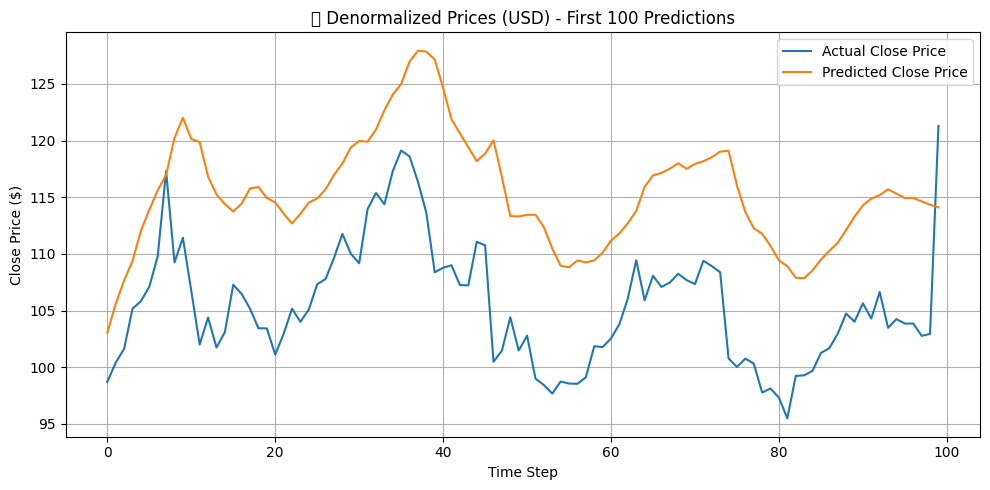

In [18]:
# Only extract the same 5 features used in scaling
# ['Open', 'High', 'Low', 'Close', 'Volume']

# Reconstruct dummy 5-column feature sets to inverse scale
X_last = X_test[:100, -1, :]  # last time step of each sequence
X_open = X_last[:, 0].reshape(-1, 1)
X_high = X_last[:, 1].reshape(-1, 1)
X_low  = X_last[:, 2].reshape(-1, 1)
X_volume = X_last[:, 4].reshape(-1, 1)

# Combine with y_true and y_pred for reverse transform
Xy_true = np.hstack([X_open, X_high, X_low, y_true[:100].reshape(-1, 1), X_volume])
Xy_pred = np.hstack([X_open, X_high, X_low, y_pred[:100].reshape(-1, 1), X_volume])

# Inverse transform to get actual values
real_true = scaler.inverse_transform(Xy_true)[:, 3]  # index 3 is Close
real_pred = scaler.inverse_transform(Xy_pred)[:, 3]

# Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(real_true, label="Actual Close Price")
plt.plot(real_pred, label="Predicted Close Price")
plt.title("📉 Denormalized Prices (USD) - First 100 Predictions")
plt.xlabel("Time Step")
plt.ylabel("Close Price ($)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [19]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
from scipy.stats import pearsonr

# True vs Predicted (real prices)
rmse = np.sqrt(mean_squared_error(real_true, real_pred))
mae = mean_absolute_error(real_true, real_pred)
r2 = r2_score(real_true, real_pred)
corr, _ = pearsonr(real_true, real_pred)

print("📊 Evaluation Metrics (Real Prices, USD)")
print(f"🔹 RMSE : ${rmse:.2f}")
print(f"🔹 MAE  : ${mae:.2f}")
print(f"🔹 R²   : {r2:.4f}")
print(f"🔹 Pearson Correlation (r): {corr:.4f}")


📊 Evaluation Metrics (Real Prices, USD)
🔹 RMSE : $10.59
🔹 MAE  : $10.06
🔹 R²   : -2.9575
🔹 Pearson Correlation (r): 0.7374
